In [1]:
import pandas as pd
import numpy as np #toán
import matplotlib.pyplot as plt#Vẽ đồ thị cơ bản -> vẽ biểu đồ Revenue theo thời gian và feature quan trọng
import seaborn as sns #Vẽ đồ thị nâng cao
from lightgbm import LGBMRegressor
# LGBMRegressor: mô hình LightGBM để dự báo số (regression)
# → Đây là mô hình chính để dự báo Revenue
# → Lý do chọn LightGBM: nhanh, chính xác, xử lý tốt time series
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# mean_absolute_error → tính MAE (yêu cầu của đề bài)
# mean_squared_error  → tính RMSE (yêu cầu của đề bài)
# r2_score            → tính R² (yêu cầu của đề bài)
import warnings
warnings.filterwarnings('ignore')

# warnings: ẩn các cảnh báo không quan trọng
# → Giúp output gọn gàng hơn khi chạy

SEED = 42
np.random.seed(SEED)
#Đặt see để kết quả phải được tái lập nghĩa là nếu mình chạy nó ra như vậy thì người khác cũng sẽ chạy ra như vậy

In [2]:
sales        = pd.read_csv("sales.csv", parse_dates=["Date"])
orders       = pd.read_csv("orders.csv", parse_dates=["order_date"])
order_items  = pd.read_csv("order_items.csv")
payments     = pd.read_csv("payments.csv")
promotions   = pd.read_csv("promotions.csv", parse_dates=["start_date", "end_date"])
returns      = pd.read_csv("returns.csv", parse_dates=["return_date"])
web_traffic  = pd.read_csv("web_traffic.csv", parse_dates=["date"])
reviews      = pd.read_csv("reviews.csv", parse_dates=["review_date"])

print("Load xong tất cả file!")
print(f"Sales: {sales.shape}, Orders: {orders.shape}, Web traffic: {web_traffic.shape}")

FileNotFoundError: [Errno 2] No such file or directory: 'sales.csv'

In [ ]:
#chạy nhanh hơn



# 3.1 Orders + Payments
orders_payments = orders.merge(payments, on="order_id", how="left")
daily_orders = orders_payments.groupby("order_date").agg(
    num_orders    = ("order_id", "count"),
    total_payment = ("payment_value", "sum"),
    avg_payment   = ("payment_value", "mean"),
    num_cod       = ("payment_method_x", lambda x: (x == "cod").sum()),
    num_credit    = ("payment_method_x", lambda x: (x == "credit_card").sum()),
    num_mobile    = ("device_type", lambda x: (x == "mobile").sum()),
).reset_index().rename(columns={"order_date": "Date"})
print("Done 3.1")

# 3.2 Order items — NHANH HƠN: dùng map thay vì merge
order_date_map = orders.set_index("order_id")["order_date"]
order_items["order_date"] = order_items["order_id"].map(order_date_map)
daily_items = order_items.groupby("order_date").agg(
    total_quantity   = ("quantity", "sum"),
    total_discount   = ("discount_amount", "sum"),
    num_promo_orders = ("promo_id", lambda x: x.notna().sum()),
).reset_index().rename(columns={"order_date": "Date"})
print("Done 3.2")

# 3.3 Returns
daily_returns = returns.groupby("return_date").agg(
    total_refund = ("refund_amount", "sum"),
    num_returns  = ("return_id", "count"),
).reset_index().rename(columns={"return_date": "Date"})
print("Done 3.3")

# 3.4 Web traffic
web_daily = web_traffic.groupby("date").agg(
    total_sessions  = ("sessions", "sum"),
    total_visitors  = ("unique_visitors", "sum"),
    total_pageviews = ("page_views", "sum"),
    avg_bounce_rate = ("bounce_rate", "mean"),
).reset_index().rename(columns={"date": "Date"})
print("Done 3.4")

# 3.5 Reviews
daily_reviews = reviews.groupby("review_date").agg(
    avg_rating  = ("rating", "mean"),
    num_reviews = ("review_id", "count"),
).reset_index().rename(columns={"review_date": "Date"})
print("✅ Done 3.5")

# 3.6 Promotions — NHANH HƠN: không dùng vòng for
all_dates = pd.date_range(sales["Date"].min(), "2024-07-01", freq="D")
promo_flags = pd.DataFrame({"Date": all_dates})

# Dùng vectorized thay vì vòng lặp for
promo_flags["has_promotion"] = promo_flags["Date"].apply(
    lambda d: int(any(
        row["start_date"] <= d <= row["end_date"]
        for _, row in promotions.iterrows()
    ))
)
print("Done 3.6")


✅ Done 3.1
✅ Done 3.2
✅ Done 3.3
✅ Done 3.4
✅ Done 3.5
✅ Done 3.6


In [ ]:
#MERGE TẤT CẢ
df = sales.copy()
df = df.merge(daily_orders,  on="Date", how="left")
df = df.merge(daily_items,   on="Date", how="left")
df = df.merge(daily_returns, on="Date", how="left")
df = df.merge(web_daily,     on="Date", how="left")
df = df.merge(daily_reviews, on="Date", how="left")
df = df.merge(promo_flags,   on="Date", how="left")

# Điền 0 cho các ngày không có dữ liệu
df = df.fillna(0)

print("Merge xong!")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

✅ Merge xong!
Shape: (3833, 21)
Columns: ['Date', 'Revenue', 'COGS', 'num_orders', 'total_payment', 'avg_payment', 'num_cod', 'num_credit', 'num_mobile', 'total_quantity', 'total_discount', 'num_promo_orders', 'total_refund', 'num_returns', 'total_sessions', 'total_visitors', 'total_pageviews', 'avg_bounce_rate', 'avg_rating', 'num_reviews', 'has_promotion']


In [ ]:
# Tạo data Features và Lag Features

#Hiện tại bảng df chỉ có các features từ các file khác. Nhưng mô hình cần thêm 2 loại features rất quan trọng:
#Loại 1 — Date Features: Trích xuất thông tin từ cột Date

#Mô hình không hiểu "2012-07-04" là gì, nhưng hiểu được số 7 (tháng 7), số 3 (thứ 4), số 2012 (năm)...

#Loại 2 — Lag Features: Lấy Revenue của các ngày trước đó

#Doanh thu hôm nay thường liên quan đến hôm qua, tuần trước, năm trước → đây là features mạnh nhất trong time series!

df = df.sort_values("Date").reset_index(drop = True)

# Data Feature
# Ngày trong tuần ví dú thứ 2 là 0 , thứ chủ nhật là 6
df["day_of_week"] = df["Date"].dt.dayofweek

#ngày trong tháng
df["day_of_month"] = df["Date"].dt.day
#thangs
df["month"] = df["Date"].dt.month
# Quý: 1-4
df["quarter"] = df["Date"].dt.quarter
# Năm
df["year"] = df["Date"].dt.year
# Ngày thứ mấy trong năm: 1-365
df["day_of_year"] = df["Date"].dt.dayofyear
# Tuần thứ mấy trong năm: 1-52
df["week_of_year"] = df["Date"].dt.isocalendar().week.astype(int)
# Có phải cuối tuần không: 1=có, 0=không
df["is_weekend"]   = (df["day_of_week"] >= 5).astype(int)



# Lag Feature
# Lag = lấy Revenue của N ngày trước
# Ví dụ lag_1 của ngày 05/07 = Revenue của ngày 04/07

df["lag_1"]   = df["Revenue"].shift(1)   # hôm qua
df["lag_7"]   = df["Revenue"].shift(7)   # tuần trước
df["lag_14"]  = df["Revenue"].shift(14)  # 2 tuần trước
df["lag_30"]  = df["Revenue"].shift(30)  # tháng trước
df["lag_365"] = df["Revenue"].shift(365) # năm ngoái cùng ngày
df["lag_90"]  = df["Revenue"].shift(90)   # thêm mới
df["lag_180"] = df["Revenue"].shift(180)  # thêm mới


# Thêm vào BƯỚC 5 sau các lag hiện tại
# Lag cố định từ 2022 → dùng thẳng cho 2023 mà không cần recursive
df["lag_366"]  = df["Revenue"].shift(366)   # năm ngoái + 1 ngày
df["lag_364"]  = df["Revenue"].shift(364)   # năm ngoái - 1 ngày
df["lag_363"]  = df["Revenue"].shift(363)   # năm ngoái - 2 ngày
# Rolling feature 
#Rolling feature (còn gọi là rolling statistics) là cách bạn lấy một cửa sổ (window) các giá trị gần đây trong quá khứ rồi tính toán thống kê như trung bình, độ lệch chuẩn, min, max…

df["rolling_mean_7"]  = df["Revenue"].shift(1).rolling(7).mean() # phải shift một là dời về một ngày ví dụ rolling mean của ngày 10/10 đi thì rolling mean 7 của nó phải bao gồm ngày 3 4 5 6 7 8 9 nếu ko shift 1 thì nó sẽ có ngày 10 là sai vi phạm
# Trung bình 30 ngày gần nhất
df["rolling_mean_30"] = df["Revenue"].shift(1).rolling(30).mean()
# Độ lệch chuẩn 7 ngày (đo mức độ biến động)
df["rolling_std_7"]   = df["Revenue"].shift(1).rolling(7).std()
#lấy độ lệch chuẩn để dadaanhs giá sự tăng giảm doanh thu giữa các ngày 

# Trung bình 90 ngày gần nhất (xu hướng dài hạn)
df["rolling_mean_90"] = df["Revenue"].shift(1).rolling(90).mean()

df["rolling_mean_365"] = df["Revenue"].shift(1).rolling(365).mean()  # thêm mới
df["rolling_max_7"]    = df["Revenue"].shift(1).rolling(7).max()     # thêm mới
df["rolling_min_7"]    = df["Revenue"].shift(1).rolling(7).min()  


# Lag features sẽ tạo ra NaN ở các dòng đầu
# Ví dụ: lag_365 → 365 dòng đầu tiên sẽ là NaN
# → Xóa các dòng NaN này đi

df = df.dropna()
df = df.reset_index(drop=True)


print(f"Shape sau bước 5: {df.shape}")
print(f"Tổng số features: {df.shape[1]}")
print(f"Tên các cột:\n{df.columns.tolist()}")

Shape sau bước 5: (3467, 46)
Tổng số features: 46
Tên các cột:
['Date', 'Revenue', 'COGS', 'num_orders', 'total_payment', 'avg_payment', 'num_cod', 'num_credit', 'num_mobile', 'total_quantity', 'total_discount', 'num_promo_orders', 'total_refund', 'num_returns', 'total_sessions', 'total_visitors', 'total_pageviews', 'avg_bounce_rate', 'avg_rating', 'num_reviews', 'has_promotion', 'day_of_week', 'day_of_month', 'month', 'quarter', 'year', 'day_of_year', 'week_of_year', 'is_weekend', 'lag_1', 'lag_7', 'lag_14', 'lag_30', 'lag_365', 'lag_90', 'lag_180', 'lag_366', 'lag_364', 'lag_363', 'rolling_mean_7', 'rolling_mean_30', 'rolling_std_7', 'rolling_mean_90', 'rolling_mean_365', 'rolling_max_7', 'rolling_min_7']


In [ ]:
# ===== BƯỚC 6: TRAIN MÔ HÌNH =====
FEATURES_SAFE = [
    "day_of_week", "day_of_month", "month",
    "quarter", "year", "day_of_year",
    "week_of_year", "is_weekend",
    "lag_1", "lag_7", "lag_14", "lag_30", "lag_365",
    "rolling_mean_7", "rolling_mean_30",
    "rolling_std_7", "rolling_mean_90",
    "has_promotion",
    "total_sessions", "total_visitors",
    "total_pageviews", "avg_bounce_rate",
]
TARGET = "Revenue"

train = df[df["year"] <= 2021]
test  = df[df["year"] == 2022]
X_train = train[FEATURES_SAFE]
y_train = train[TARGET]
X_test  = test[FEATURES_SAFE]
y_test  = test[TARGET]

print(f"Train: {X_train.shape} ({train['Date'].min().date()} → {train['Date'].max().date()})")
print(f"Test:  {X_test.shape}  ({test['Date'].min().date()} → {test['Date'].max().date()})")

# Weights — năm gần hơn được học nhiều hơn
weights_all = df["year"].map({
    2013:1, 2014:1, 2015:1, 2016:2,
    2017:2, 2018:3, 2019:3, 2020:5,
    2021:8, 2022:10
}).fillna(1)

weights_eval = train["year"].map({
    2013:1, 2014:1, 2015:1, 2016:2,
    2017:2, 2018:3, 2019:3, 2020:5,
    2021:8
}).fillna(1)

# Model chính → train toàn bộ 2013-2022
model = LGBMRegressor(
    n_estimators  = 1000,
    learning_rate = 0.05,
    num_leaves    = 31,
    random_state  = SEED,
    n_jobs        = -1,
    verbosity     = -1
)
model.fit(
    df[FEATURES_SAFE],
    df[TARGET],                # ← target
    sample_weight=weights_all
)
print(" Train xong model chính!")

# Model eval → đánh giá nội bộ trên 2022
model_eval = LGBMRegressor(
    n_estimators  = 1000,
    learning_rate = 0.05,
    num_leaves    = 31,
    random_state  = SEED,
    n_jobs        = -1,
    verbosity     = -1
)
model_eval.fit(
    X_train,
    y_train,                    # ← target
    sample_weight=weights_eval
)
y_pred = model_eval.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"\n===== ĐÁNH GIÁ NỘI BỘ (2022) =====")
print(f"MAE  : {mae:,.0f}")
print(f"RMSE : {rmse:,.0f}")
print(f"R²   : {r2:.4f}")

Train: (3102, 22) (2013-07-05 → 2021-12-31)
Test:  (365, 22)  (2022-01-01 → 2022-12-31)
✅ Train xong model chính!

===== ĐÁNH GIÁ NỘI BỘ (2022) =====
MAE  : 586,025
RMSE : 786,547
R²   : 0.7792


In [ ]:
# 7.1 Chuẩn bị dữ liệu lịch sử để tạo lag
history  = df[["Date", "Revenue"]].copy()
real_rev = df.set_index("Date")["Revenue"]  # ← thêm để dùng lag_365 thật

future_dates = pd.date_range(
    start = "2023-01-01",
    end   = "2024-07-01",
    freq  = "D"
)
print(f"Số ngày cần dự báo: {len(future_dates)}")
print(f"Từ {future_dates.min().date()} → {future_dates.max().date()}")

predictions = []

for date in future_dates:
    rev_history = history["Revenue"].values

    row = {
        "day_of_week"  : date.dayofweek,
        "day_of_month" : date.day,
        "month"        : date.month,
        "quarter"      : date.quarter,
        "year"         : date.year,
        "day_of_year"  : date.dayofyear,
        "week_of_year" : date.isocalendar()[1],
        "is_weekend"   : int(date.dayofweek >= 5),

        "lag_1"   : rev_history[-1],
        "lag_7"   : rev_history[-7],
        "lag_14"  : rev_history[-14],
        "lag_30"  : rev_history[-30],

        # ← Hybrid lag_365: lấy data THẬT 2022 nếu có
        "lag_365" : real_rev.get(
            date - pd.Timedelta(days=365),
            rev_history[-365]
        ),

        "rolling_mean_7"  : np.mean(rev_history[-7:]),
        "rolling_mean_30" : np.mean(rev_history[-30:]),
        "rolling_std_7"   : np.std(rev_history[-7:]),
        "rolling_mean_90" : np.mean(rev_history[-90:]),

        "has_promotion" : int(promo_flags[promo_flags["Date"] == date]["has_promotion"].values[0]),

        "total_sessions"  : web_daily["total_sessions"].mean(),
        "total_visitors"  : web_daily["total_visitors"].mean(),
        "total_pageviews" : web_daily["total_pageviews"].mean(),
        "avg_bounce_rate" : web_daily["avg_bounce_rate"].mean(),
    }

    X_future = pd.DataFrame([row])[FEATURES_SAFE]
    pred = model.predict(X_future)[0]
    predictions.append(pred)

    new_row  = pd.DataFrame({"Date": [date], "Revenue": [pred]})
    history  = pd.concat([history, new_row], ignore_index=True)
    real_rev[date] = pred  # ← cập nhật để lag_365 năm 2024 dùng

print(f" Dự báo xong {len(predictions)} ngày!")

submission = pd.DataFrame({
    "Date"    : future_dates,
    "Revenue" : predictions,
})
cogs_ratio = (df["COGS"] / df["Revenue"]).mean()
submission["COGS"] = submission["Revenue"] * cogs_ratio

submission.to_csv("submission.csv", index=False)
print(f"\nRevenue TB dự báo : {submission['Revenue'].mean():,.0f}")
print(f"Revenue TB thật   : {df[df['year']==2022]['Revenue'].mean():,.0f}")
print(f"\n5 dòng đầu:\n{submission.head()}")

Số ngày cần dự báo: 548
Từ 2023-01-01 → 2024-07-01
✅ Dự báo xong 548 ngày!

✅ Đã xuất haha.csv!

Revenue TB dự báo : 3,794,756
Revenue TB thật   : 3,204,791

5 dòng đầu:
        Date       Revenue          COGS
0 2023-01-01  1.700787e+06  1.499280e+06
1 2023-01-02  1.245632e+06  1.098051e+06
2 2023-01-03  1.201391e+06  1.059051e+06
3 2023-01-04  1.176081e+06  1.036740e+06
4 2023-01-05  1.360589e+06  1.199388e+06


<Figure size 900x300 with 0 Axes>

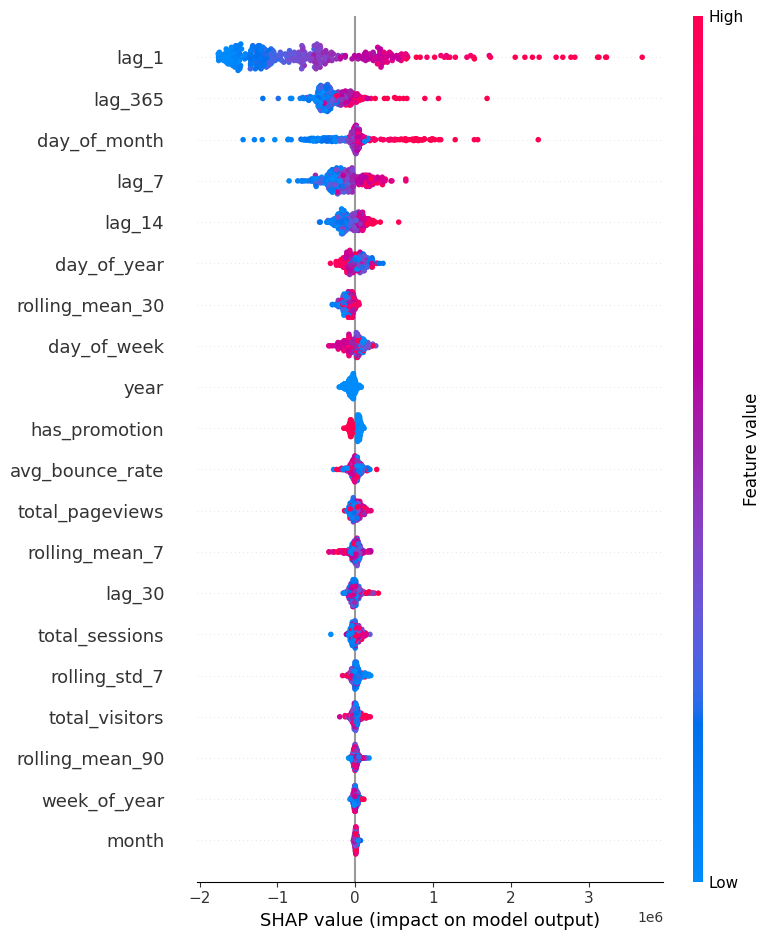

✅ Lưu shap_summary.png


In [ ]:
import shap
plt.figure(figsize=(9,3))
# Tính SHAP values
explainer  = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Vẽ biểu đồ SHAP
plt.figure()
shap.summary_plot(
    shap_values, 
    X_test, 
    show=False
)
plt.tight_layout()
plt.savefig("shap_summary.png")
plt.show()
print("✅ Lưu shap_summary.png")

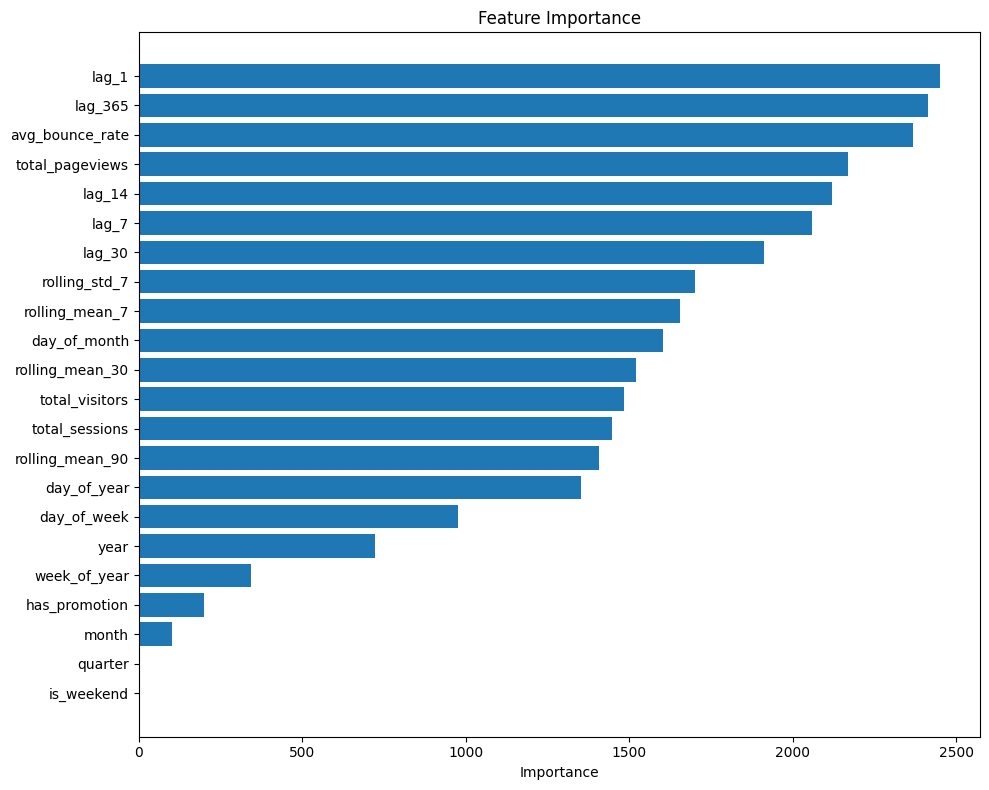

✅ Lưu feature_importance.png


In [ ]:
import matplotlib.pyplot as plt

# Vẽ biểu đồ feature importance
feat_imp = pd.DataFrame({
    "feature"   : FEATURES_SAFE,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(feat_imp["feature"], feat_imp["importance"])
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()
print("✅ Lưu feature_importance.png")

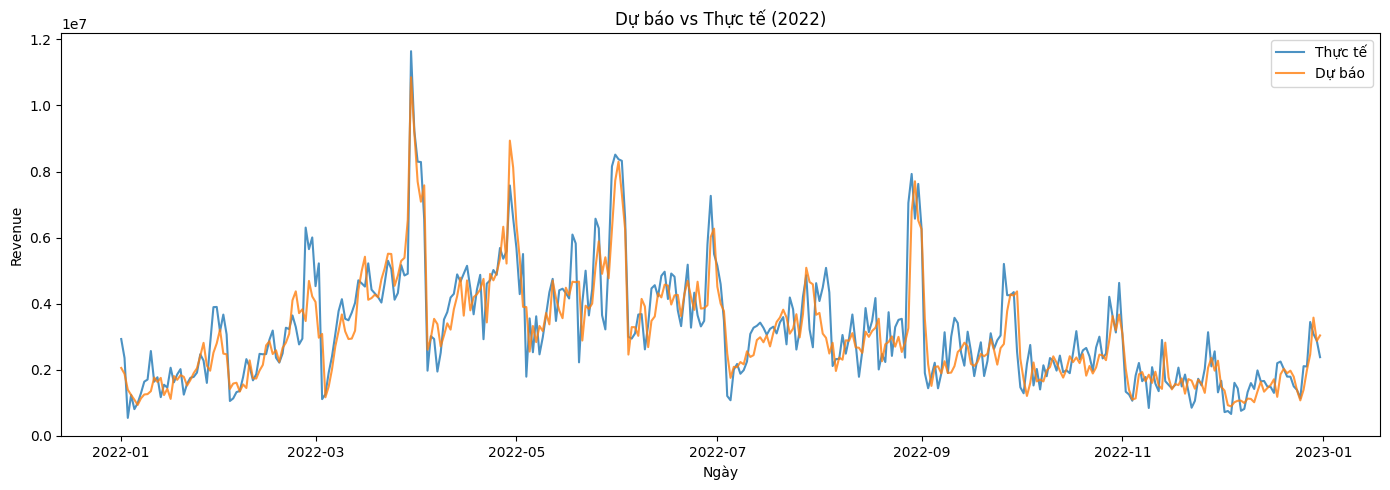

✅ Lưu forecast_vs_actual.png


In [ ]:
# Vẽ so sánh dự báo vs thực tế trên tập test
plt.figure(figsize=(14, 5))
plt.plot(test["Date"], y_test.values,  label="Thực tế",  alpha=0.8)
plt.plot(test["Date"], y_pred, label="Dự báo", alpha=0.8)
plt.title("Dự báo vs Thực tế (2022)")
plt.xlabel("Ngày")
plt.ylabel("Revenue")
plt.legend()
plt.tight_layout()
plt.savefig("forecast_vs_actual.png")
plt.show()
print("✅ Lưu forecast_vs_actual.png")